# Customer Churn Prediction Using Machine Learning

## Project Objective

The objective of this project is to predict whether a customer is likely to leave a telecom service based on customer demographics, services, and account information.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.shape


(7043, 21)

In [ ]:
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [ ]:
print(df["TotalCharges"].isnull().sum())

0


In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 22


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Final dataset shape:", df.shape)

Final dataset shape: (7021, 20)


In [ ]:
print(df["Churn"].value_counts())

Churn
No     5164
Yes    1857
Name: count, dtype: int64


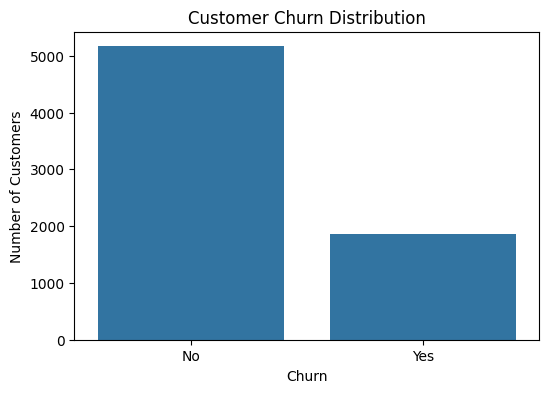

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
churn_percentage = (df["Churn"].value_counts(normalize=True) * 100)

print(churn_percentage)

Churn
No     73.550776
Yes    26.449224
Name: proportion, dtype: float64


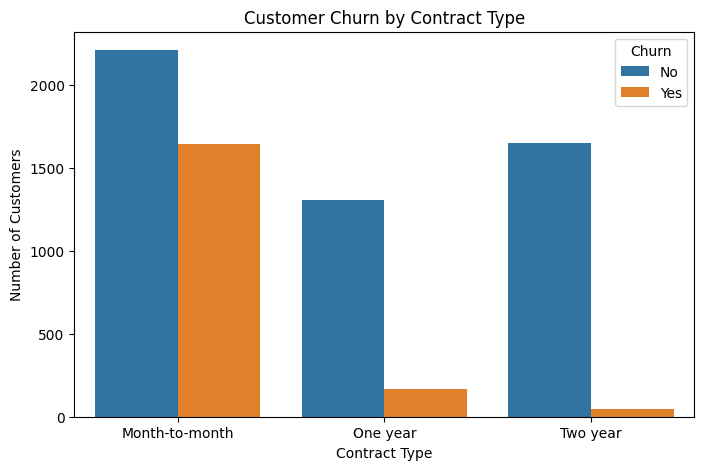

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

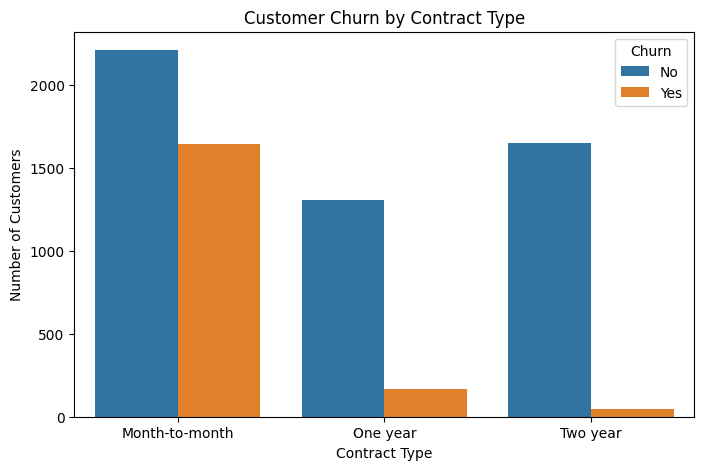

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

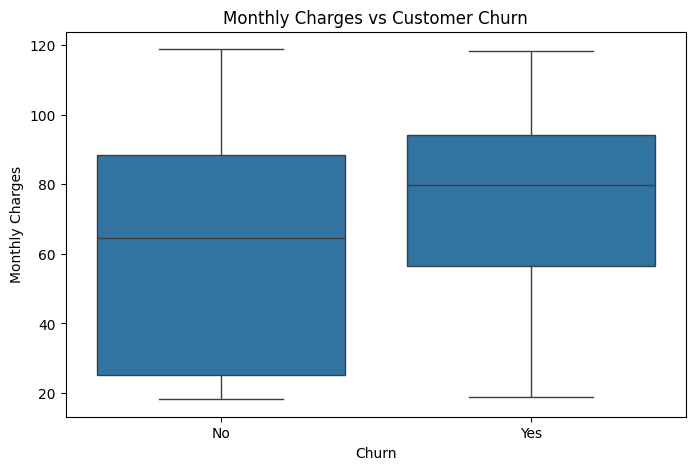

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

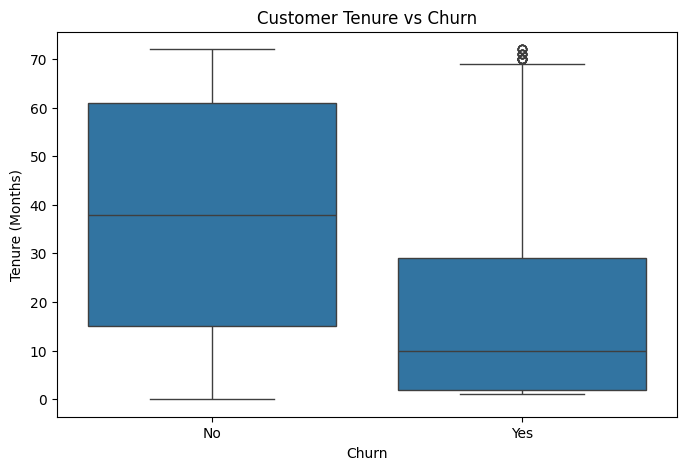

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [ ]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [ ]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [ ]:
categorical_columns = X.select_dtypes(include=["object"]).columns

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [ ]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred_lr = logistic_model.predict(X_test)

In [ ]:
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Accuracy:", accuracy_lr)
print("Recall:", recall_lr)
print("ROC-AUC:", roc_auc_lr)

Accuracy: 0.802846975088968
Recall: 0.5241935483870968
ROC-AUC: 0.8403139930674828


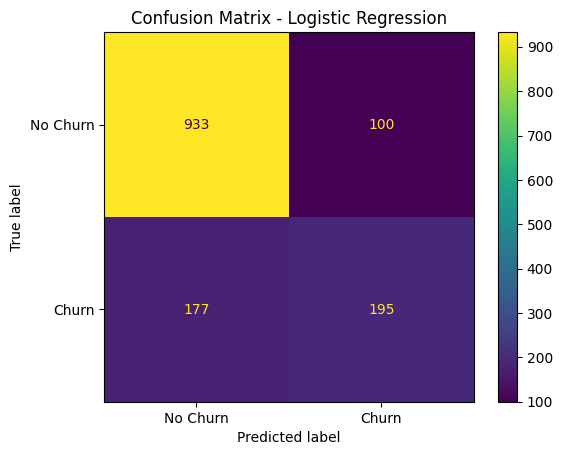

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [ ]:
random_forest_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [ ]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest Recall:", recall_rf)
print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest Accuracy: 0.7779359430604982
Random Forest Recall: 0.4435483870967742
Random Forest ROC-AUC: 0.8131382131592917


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Recall": [recall_lr, recall_rf],
    "ROC-AUC": [roc_auc_lr, roc_auc_rf]
})

comparison

,Model,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.802847,0.524194,0.840314
1,Random Forest,0.777936,0.443548,0.813138


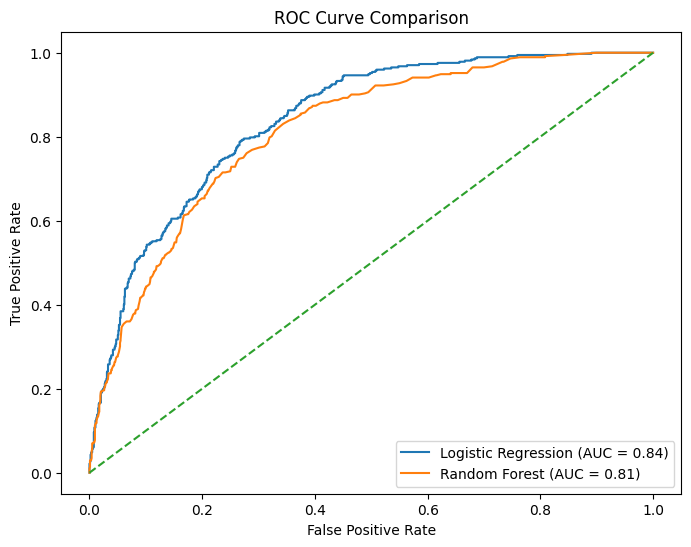

In [ ]:
from sklearn.metrics import roc_curve, auc

# Logistic Regression ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# Random Forest ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [ ]:
# Get the trained preprocessor
preprocessor_fitted = random_forest_model.named_steps["preprocessor"]

# Transform the feature names
feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance from Random Forest
importances = random_forest_model.named_steps["model"].feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Show top 10 important features
feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
3,num__TotalCharges,0.159735
1,num__tenure,0.142537
2,num__MonthlyCharges,0.138619
36,cat__Contract_Month-to-month,0.051460
18,cat__OnlineSecurity_No,0.031225
16,cat__InternetService_Fiber optic,0.028361
43,cat__PaymentMethod_Electronic check,0.028298
27,cat__TechSupport_No,0.027634
0,num__SeniorCitizen,0.019953
21,cat__OnlineBackup_No,0.017863


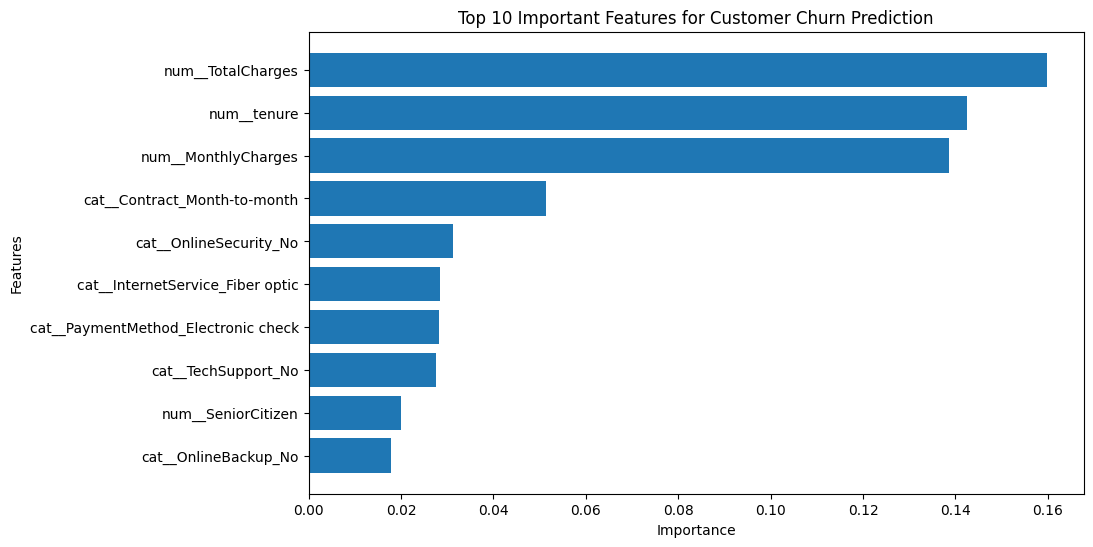

In [ ]:
top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features for Customer Churn Prediction")

plt.gca().invert_yaxis()

plt.show()

## Conclusion

This project developed machine learning models to predict customer churn using telecom customer data.

Two classification models were evaluated: Logistic Regression and Random Forest.

Logistic Regression performed better than Random Forest with an accuracy of approximately 80% and a ROC-AUC score of approximately 84%.

The analysis showed that important factors influencing customer churn include customer tenure, monthly charges, total charges, contract type, internet service, and customer support services.

Customers with month-to-month contracts and shorter tenure showed a higher risk of churn.

These insights can help telecom companies identify customers who are likely to leave and take preventive actions such as offering personalized discounts, improving customer support, and encouraging long-term contracts.


## Key Findings

- The dataset originally contained telecom customer information used to predict customer churn.
- After data cleaning, the final dataset contained 7,021 customer records.
- Approximately 26% of customers churned.
- Customers with month-to-month contracts showed a higher risk of churn.
- Customer tenure, TotalCharges, and MonthlyCharges were among the most important features.
- Logistic Regression achieved the best performance with approximately 80% accuracy and 84% ROC-AUC.